# Análisis y preprocesamiento de los datos DataONG.csv

Librerias necesarias

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Carga de datos

In [141]:
data_frame = pd.read_csv("DataONG.csv", low_memory=False)
data_frame.head()

,ODATEDW,OSOURCE,TCODE,STATE,ZIP,MAILCODE,PVASTATE,DOB,NOEXCH,RECINHSE,...,DONOR_AMOUNT,HPHONE_D,RFA_2R,RFA_2F,RFA_2A,MDMAUD_R,MDMAUD_F,MDMAUD_A,CLUSTER2,GEOCODE2
0,8901,GRI,0,IL,61081,,,3712,0,,...,0.0,0,L,4,E,X,X,X,39.0,C
1,9401,NWN,0,LA,70611,,,0,0,,...,0.0,1,L,3,E,X,X,X,38.0,C
2,9401,MSD,1,TN,37127-,,,3211,0,,...,0.0,0,L,1,F,X,X,X,34.0,B
3,8901,ENQ,0,MN,56475,,,2603,0,,...,0.0,1,L,4,D,X,X,X,57.0,D
4,9201,HCC,1,LA,70791,,,0,0,X,...,0.0,0,L,1,G,X,X,X,38.0,B


# Resumen del Diccionario de Datos (DataONG)

El archivo de datos contiene información detallada sobre donantes de una ONG, estructurada en cientos de columnas. Para facilitar su análisis, las variables se agrupan en las siguientes categorías principales:

### 1. Datos de Identificación y Contacto
*   **ODATEDW**: Fecha de la primera donación (Año/Mes).
*   **OSOURCE**: Código de la lista de correo de donde se captó originalmente al donante.
*   **TCODE**: Título del donante (Ej: Mr., Mrs., Dr., etc.).
*   **STATE / ZIP**: Estado y Código Postal de residencia.
*   **MAILCODE**: Indica si la dirección postal es válida (` `) o si tiene errores (`B`).

### 2. Datos Demográficos Personales
*   **DOB**: Fecha de nacimiento.
*   **AGE / AGEFLAG**: Edad del donante y si es exacta o inferida.
*   **GENDER**: Género (M=Hombre, F=Mujer, U=Desconocido, J=Cuenta Conjunta).
*   **INCOME**: Nivel de ingresos del hogar (escala categórica).
*   **WEALTH1 / WEALTH2**: Índice de riqueza relativa según el estado o código postal.
*   **HOMEOWNR**: Indica si el donante es propietario de su vivienda.
*   **CHILD03 a CHILD18 / NUMCHLD**: Presencia y cantidad de niños en el hogar separados por rangos de edad.

### 3. Historial de Relación con la ONG
*   **NOEXCH**: Indicador de si la información del donante puede compartirse o intercambiarse con otras organizaciones.
*   **RECINHSE / RECP3 / RECPGVG / RECSWEEP**: Diferentes flags que indican si el donante ha participado en programas internos específicos de la ONG (Planned Giving, Sweepstakes, etc.).
*   **SOLP3 / SOLIH**: Límites de solicitud (indica cuántas veces al año se le puede enviar correspondencia al donante).
*   **MAJOR**: Indica si es considerado un donante importante ("Mayor Donor").
*   **PEPSTRFL**: Indica si el donante tiene estatus "PEP Star" (frecuente o leal).

### 4. Intereses y Hábitos de Consumo (Datos de Terceros)
*   **HIT**: Número de veces que el donante ha respondido a ofertas por correo de terceros (otras organizaciones).
*   **MB... / MAG... / PUB...** (Ej: `MBCRAFT`, `MAGFAML`, `PUBHLTH`): Variables que indican si compran productos por correo o se suscriben a revistas específicas (manualidades, jardinería, salud, etc.).
*   **Intereses** (Ej: `COLLECT1`, `VETERANS`, `BIBLE`, `PETS`): Flags booleanos que marcan los intereses conocidos del donante.

### 5. Datos Censales del Vecindario (Geodemográficos)
Se extrajo información del censo para caracterizar el entorno donde vive el donante. Estas variables suelen estar agrupadas por prefijos:
*   **POP90... / ETH...**: Tamaño de la población local y distribución étnica.
*   **AGE90... / CHIL... / HHAGE...**: Distribución por edades de la población del vecindario.
*   **DW... / HV... / HU... / RP...**: Características de vivienda (proporción de dueños vs arrendatarios, valor promedio de casas, costo de rentas).
*   **IC... / HHAS...**: Distribución de ingresos en la zona y uso de asistencia social.
*   **OCC... / EIC... / EC...**: Tipos de ocupación predominantes, industrias de empleo y nivel de escolaridad.
*   **LFC... / AFC... / VC...**: Participación en fuerza laboral, presencia de militares activos y veteranos.

### 6. Historial de Campañas y Promociones
*   **ADATE_2 a ADATE_24**: Fechas exactas en las que se enviaron campañas promocionales anteriores.
*   **RDATE_3 a RDATE_24**: Fecha en la que el donante realizó un pago o donación en respuesta a una campaña específica.
*   **RAMNT_3 a RAMNT_24**: El monto exacto de la donación hecha en respuesta a esas campañas.
*   **RFA_2 a RFA_24**: Estatus RFA de campañas pasadas (Recencia, Frecuencia y Monto de donación).

### 7. Métricas Agregadas de Donación (Resumen de Comportamiento)
*   **RAMNTALL / NGIFTALL**: Monto monetario total donado históricamente y el número total de donaciones realizadas.
*   **MINRAMNT / MAXRAMNT / AVGGIFT**: Donación histórica más baja, más alta y el monto promedio por donación.
*   **FISTDATE / LASTDATE / LASTGIFT**: Fecha de la primera donación, fecha de la última donación y el monto de esa última donación.
*   **TIMELAG**: Tiempo transcurrido (en meses) entre la primera y la segunda donación.
*   **MDMAUD**: Matriz y código para describir la frecuencia y monto de los grandes donantes.

### 8. Variables Objetivo (Target)
*   **DONOR_FLAG**: Indica si el donante respondió afirmativamente a la campaña de correo actual (Variable a predecir para modelos de Clasificación).
*   **DONOR_AMOUNT**: Indica el monto específico donado en la campaña actual (Variable a predecir para modelos de Regresión).


## Analisis General

1. Conocer la cantidad de obsevaciones y la cantidad de características
2. Averiguar si existen datos nulos
3. Conocer la cantidad de columnas categóricas y numéricas (recuerde que muchos algoritmos
trabajan solo con columnas numéricas y, eventualmente, hay que transformarlas)

In [116]:
#Dimenciones
data_frame.shape

(47720, 481)

In [117]:
#Buscador de nulos
data_frame.isnull().any().any()

np.True_

In [118]:
#Sumar valores nulos para resumir
print(data_frame.isnull().sum()[data_frame.isnull().sum() > 0].to_string())


CLUSTER      1141
AGE         11874
NUMCHLD     41485
INCOME      10703
WEALTH1     22350
MBCRAFT     26410
MBGARDEN    26410
MBBOOKS     26410
MBCOLECT    26441
MAGFAML     26410
MAGFEM      26410
MAGMALE     26410
PUBGARDN    26410
PUBCULIN    26410
PUBHLTH     26410
PUBDOITY    26410
PUBNEWFN    26410
PUBPHOTO    26410
PUBOPP      26410
DATASRCE    10700
SOLP3       47643
SOLIH       44669
WEALTH2     21951
GEOCODE     40187
LIFESRC     27025
MSA            46
ADI            46
DMA            46
ADATE_3       970
ADATE_4      1087
ADATE_5     16768
ADATE_6      1785
ADATE_7      4398
ADATE_8      1770
ADATE_9      5672
ADATE_10    16370
ADATE_11     5170
ADATE_12     4423
ADATE_13    20122
ADATE_14     9515
ADATE_15    32795
ADATE_16    10245
ADATE_17    13729
ADATE_18    10592
ADATE_19    12241
ADATE_20    25100
ADATE_21    17569
ADATE_22    12746
ADATE_23    28149
ADATE_24    18504
RDATE_3     47604
RDATE_4     47591
RDATE_5     47718
RDATE_6     47339
RDATE_7     43284
RDATE_8   

In [119]:
print(data_frame.isnull().sum().sum())


2751061


<Axes: >

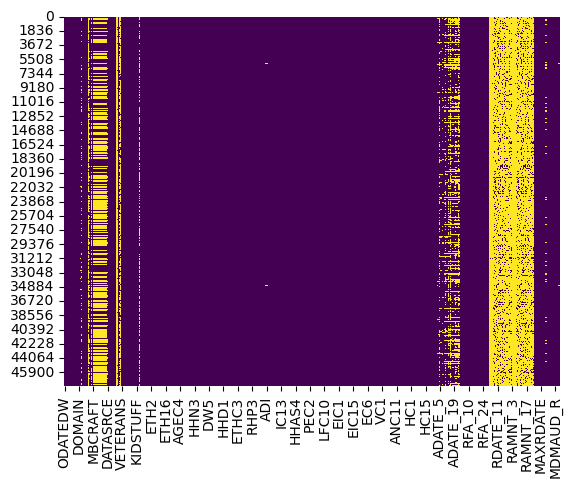

In [143]:
sns.heatmap(data_frame.isnull(), cbar=False, cmap='viridis')

In [120]:
# Agrupación de las columnas por tipo de datos
tipos = data_frame.columns.to_series().groupby(data_frame.dtypes).groups
# Conociendo la lista de columnas categóricas
ctext = tipos[np.dtype('object')]
len(ctext) # cantidad de columnas con datos categóricos.

68

In [121]:
# Conociendo la lista de columnas numéricas
columnas = data_frame.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)

413

## Tratamiento de los Nulos

Luego del analisis anterior quedo en evidencia la existencia de nulos, a continuacion se hara el devido trato para contrarrestarlos.

In [122]:
# Completando valores faltantes datos cuantititavos
for columna in cnum:
    mean = data_frame[columna].mean()
    data_frame[columna] = data_frame[columna].fillna(mean)


In [123]:
# Completando valores faltantes datos categóricos
for columna in ctext:
 mode = data_frame[columna].mode()[0]
 data_frame[columna] = data_frame[columna].fillna(mode)

In [124]:
# Se vuelve a comprobar los nulos
data_frame.isnull().any().any()

np.False_

In [125]:
# Guardando el dataset preprocesado
# Save transform datasets
data_frame.to_csv("DataONG_procesado.csv", index=False)

In [126]:
# Calculando el porcentaje de donantes sobre toda la base de datos
porcent_donantes = (data_frame[data_frame.DONOR_AMOUNT > 0]['DONOR_AMOUNT'].
  count() * 1.0/ data_frame['DONOR_AMOUNT'].count()) * 100.0
print("El procentaje de donantes es {0:.2f}%"
.format(porcent_donantes))

El procentaje de donantes es 5.08%


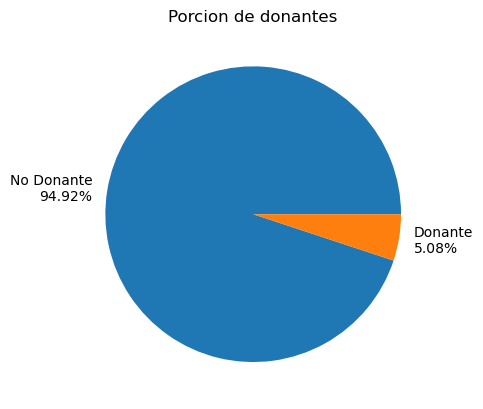

In [127]:
# Gráfico de tortas del porcentaje de donantes
# Agrupando por DONOR_FLAG
donantes = data_frame.groupby('DONOR_FLAG').IDX.count()
# Creando las leyendas del grafico.
labels = [ 'Donante\n' + str(round(x * 1.0 / donantes.sum() *
100.0, 2)) + '%' for x in donantes ]
labels[0] = 'No ' + labels[0]
plt.pie(donantes, labels=labels)
plt.title('Porcion de donantes')
plt.show()

## Análisis del gráfico
Se ve que el porcentaje de personas que fueron donantes en el pasado es realmente muy bajo, solo
un 5.08% del total de personas (2423).

Este es un dato importante a tener en cuenta si se pretende, por ejemplo, clasificar; ya que al existir
tanta diferencia entre las clases a clasificar, esto puede afectar considerablemente al algoritmo de
aprendizaje.

Conviene ahora explorar con más detalle a este grupo pequeño de personas que fueron donantes;
veamos por ejemplo como se dividen de acuerdo a la cantidad de dinero donado.

In [128]:
# Creando subset con solo los donates
data_donantes = data_frame[data_frame.DONOR_AMOUNT > 0]
data_donantes.shape

(2423, 481)

In [129]:
# Analizando el importe de donanciones
# Creando un segmentos de montos
monto_segm = pd.cut(data_donantes['DONOR_AMOUNT'], [0, 10, 20, 30, 40, 50, 60, 100, 200])

C:\Users\germa\AppData\Local\Temp\ipykernel_23156\2670681068.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot = pd.value_counts(monto_segm).plot(kind='bar', title='Montos de donación')


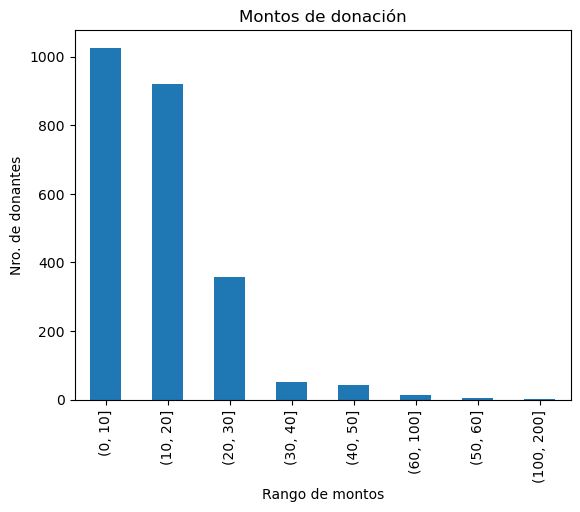

In [130]:
# Creando el grafico de barras desde pandas
plot = pd.value_counts(monto_segm).plot(kind='bar', title='Montos de donación')
plot.set_ylabel('Nro. de donantes')
plot.set_xlabel('Rango de montos')
plt.show()

Es posible apreciar que la mayor cantidad de montos de donaciones se encuentra entre el rango 0
y 30

In [131]:
# Agrupación por segmento según monto donado.
pd.value_counts(monto_segm)

C:\Users\germa\AppData\Local\Temp\ipykernel_23156\2166427984.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(monto_segm)


DONOR_AMOUNT
(0, 10]       1026
(10, 20]       921
(20, 30]       358
(30, 40]        53
(40, 50]        43
(60, 100]       15
(50, 60]         4
(100, 200]       3
Name: count, dtype: int64

## Responder a algunas preguntas

### ¿Cuál es el promedio de donaciones?

In [132]:
# Monto de donación promedio
data_donantes['DONOR_AMOUNT'].mean()

np.float64(15.598237721832438)

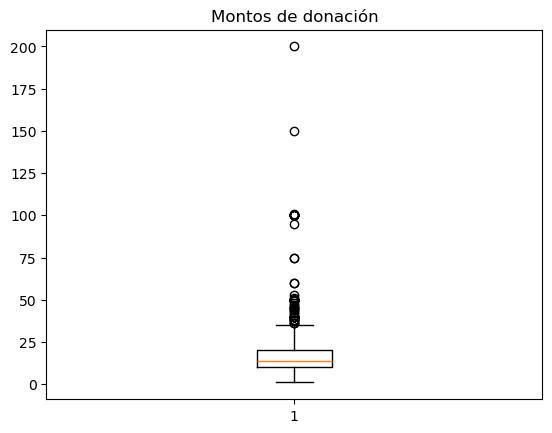

In [133]:
# Gráfico de cajas del importe de donación
plt.boxplot(list(data_donantes['DONOR_AMOUNT']))
plt.title('Montos de donación')
plt.show()

### Analizando el gráfico
Este análisis muestra que la mayor cantidad de donaciones caen en un rango de importes entre 0 y
30 (tal y como se había eomentado antes), siendo la donación promedio 15.60. También es posible
ver que donaciones que superen un importe de 50 son casos realmente poco frecuentes, por lo que
constituyen valores atípicos y sería prudente eliminar estos casos al entrenar el modelo para que no
distorsionen los resultados.

Otra exploración interesante que se podría realizar sobre el set de datos relacionado con los donantes,
es ver cómo se divide este grupo en términos de género y edad

¿Cuál es la distribución de los donantes por género?

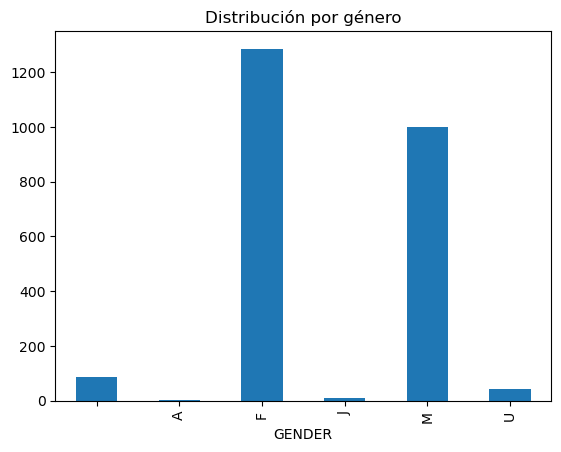

In [134]:
# Gráfico del género de los donantes
data_donantes.groupby('GENDER').size().plot(kind='bar')
plt.title('Distribución por género')
plt.show()

¿Cuál es la distribución de las donaciones según el género?

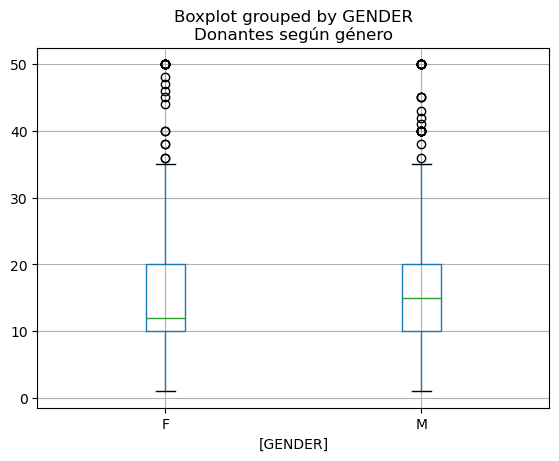

In [135]:
# Donaciones segùn el género
data_donantes[(data_donantes.DONOR_AMOUNT <= 50)
& (data_donantes.GENDER.isin(['F', 'M'])
)][['DONOR_AMOUNT', 'GENDER']].boxplot(by='GENDER')
plt.title('Donantes según género')
plt.show()

In [136]:
# Media de monto donado por mujeres
data_donantes[data_donantes.GENDER == 'F'][['DONOR_AMOUNT']].mean()

DONOR_AMOUNT    14.610311
dtype: float64

In [137]:
# Media de monto donado por hombres
data_donantes[data_donantes.GENDER == 'M'][['DONOR_AMOUNT']].mean()

DONOR_AMOUNT    16.81989
dtype: float64

### Análisis de resultados
Las mujeres suelen estar más propensas a donar, aunque donan un monto promedio menor (14.61)
al que donan los hombres (16.82).

¿Cuál es la distribución de los donantes según edad?

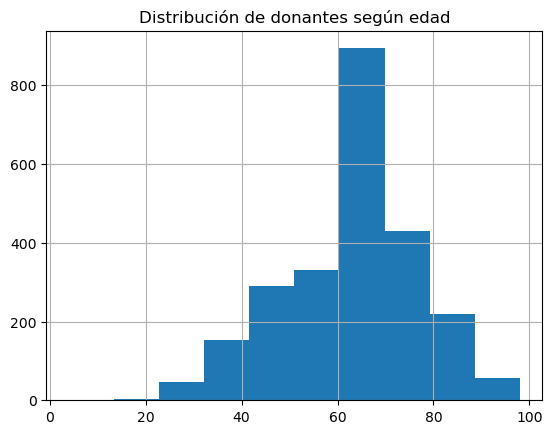

In [138]:
# Distribución de la edad de los donantes
data_donantes['AGE'].hist().set_title('Distribución de donantes según edad')
plt.show()

Para mejorar la visualización se genera el gráfico considerando rango de edades

C:\Users\germa\AppData\Local\Temp\ipykernel_23156\2338969066.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(rango_edades).plot(kind='bar', title='Donaciones por rango de edad')


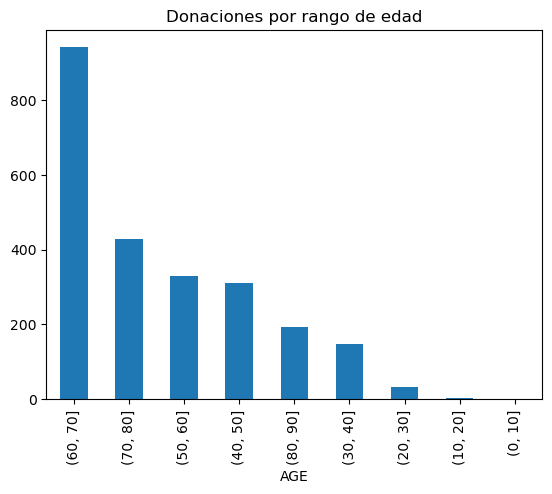

In [139]:
# Agrupando la edad por rango de a 10
rango_edades = pd.cut(data_donantes['AGE'], range(0, 100, 10))
# Gráfico de barras de donaciones por edad
pd.value_counts(rango_edades).plot(kind='bar', title='Donaciones por rango de edad')
plt.show()

### Análisis resultados
>En este último análisis es posible apreciar que la mayor cantidad de los donantes son individuos
cuya edad se encuentra entre los 60 y 70 años, aunque la media de monto donado más alta la tienen
las personas que van desde los 30 a los 60 años.

## Trabajo futuro ...
>En las próximas experiencias es posible continuar con el ejemplo completando los restantes pasos
que incluye un proyecto de Minería de datos hasta llegar al modelo y poder utilizarlo para,
por ejemplo, realizar predicciones (selección de atributos - armado de modelo - entrenamiento -
evaluación - métricas - predicción).

---